# Example - Plotting Gotchas

This example covers common gotchas/workarounds and best practices when visualizing rasters with `rioxarray` and `matplotlib`/`xarray`'s built-in plotting.

**Topics covered:**
- [Singleband rasters](#-Singleband-rasters)
- [RGB rasters](#-RGB-rasters)
- [Large rasters](#-Large-rasters)
- [Preventing `spatial_ref = 0` in plot title](#-Preventing-spatial_ref-=-0-in-plot-title)

In [ ]:
import rioxarray
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

## Singleband rasters

When opening a singleband raster (e.g. a DEM or a single spectral band), `rioxarray` returns a 3D `DataArray` (`band`, `y`, `x`), with a `band` dimension of size 1.

However, when trying to call `.plot.imshow()`, it raises a `ValueError` because `.imshow` strictly expects a 2D array (or a 3/4-band array with `rgb=` specified).

For this reason, it is needed to reduce it into a 2D array by collapsing the `band` dimension before plotting.

This can be done with 2 options:

- using [`.sel()`](https://docs.xarray.dev/en/stable/generated/xarray.DataArray.sel.html#xarray.DataArray.sel)

In [13]:
xds = rioxarray.open_rasterio("https://prd-tnm.s3.amazonaws.com/StagedProducts/Elevation/13/TIFF/current/n42w091/USGS_13_n42w091.tif")
print(xds.shape)

(1, 10812, 10812)


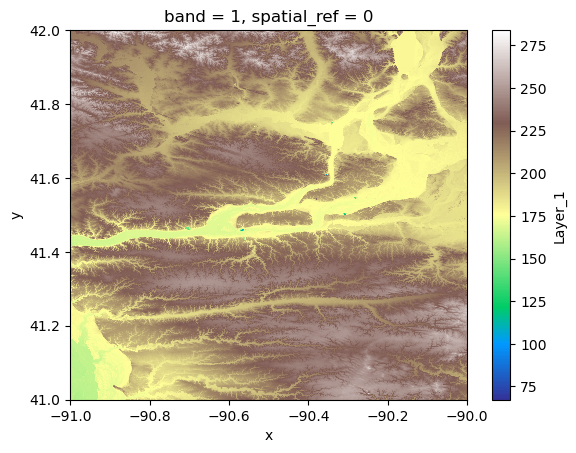

In [15]:
xds.sel(band=1).plot.imshow(cmap="terrain")

- using [`.squeeze()`](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.squeeze.html)

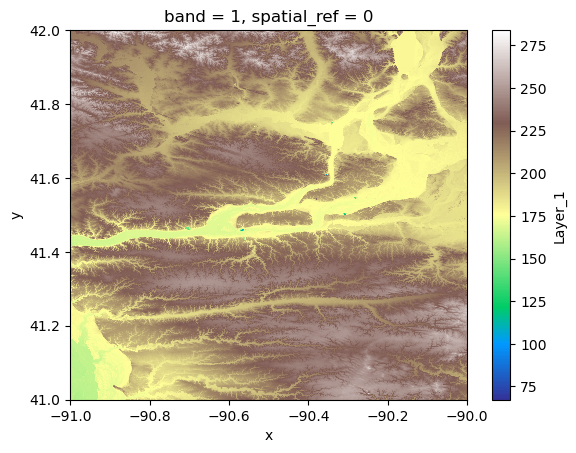

In [4]:
xds = rioxarray.open_rasterio("https://prd-tnm.s3.amazonaws.com/StagedProducts/Elevation/13/TIFF/current/n42w091/USGS_13_n42w091.tif").squeeze()
xds.plot.imshow(cmap="terrain")

## RGB rasters

RGB (or RGBA) rasters have 3 (or 4) bands, and by default `xarray`'s `.plot()` will try to plot all bands as separate 2D slices.

A good practice is to use `.plot.imshow()` with specifying the `rgb=` parameter pointing to the band dimension, as follows:

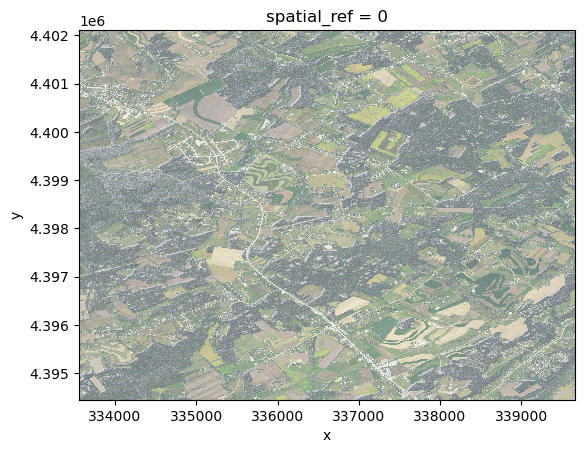

In [34]:
xds = rioxarray.open_rasterio("https://naipeuwest.blob.core.windows.net/naip/v002/md/2013/md_100cm_2013/39076/m_3907617_ne_18_1_20130924.tif")
xds.plot.imshow(rgb="band")

### Float RGB rasters

For rasters using float values, `matplotlib` expects values between **[0, 1]**, otherwise it will raise the following error message:
> *Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).*

To avoid it, it is recommanded to normalize the data before plotting:

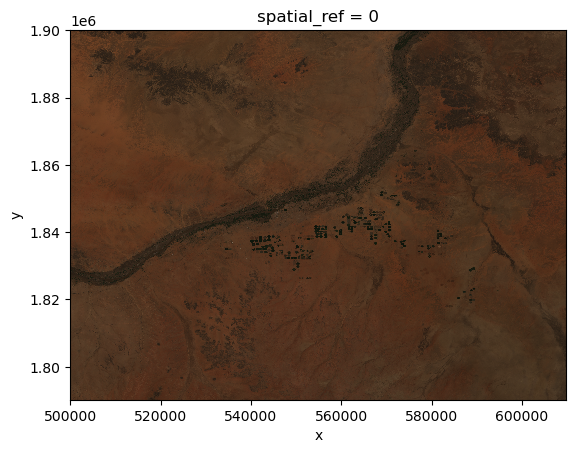

In [51]:
b04 = rioxarray.open_rasterio("https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/36/Q/WD/2020/7/S2A_36QWD_20200701_0_L2A/B04.tif")
b03 = rioxarray.open_rasterio("https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/36/Q/WD/2020/7/S2A_36QWD_20200701_0_L2A/B03.tif")
b02 = rioxarray.open_rasterio("https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/36/Q/WD/2020/7/S2A_36QWD_20200701_0_L2A/B02.tif")

rgb_float = xr.concat([b04, b03, b02], dim="band").astype("float32")

rgb_normalized = (rgb_float / 10000.0).clip(0, 1)
rgb_normalized.plot.imshow(rgb="band")
plt.show()

## Large rasters

Trying to visualize large rasters may sometimes lead to memory overload or may take a while to display.

There are a few strategies that can be used to avoid this issue.

### Lazy loading with [`dask`](https://docs.dask.org/en/stable/)

Passing the argument `chunks` when opening the raster with [`rioxarray.open_rasterio`](https://corteva.github.io/rioxarray/stable/rioxarray.html#rioxarray-open-rasterio) will create a `dask`-backed array. Data will only be read from disk when actually needed.

*Note: see also [Reading and Writing with Dask](https://corteva.github.io/rioxarray/stable/examples/dask_read_write.html)*

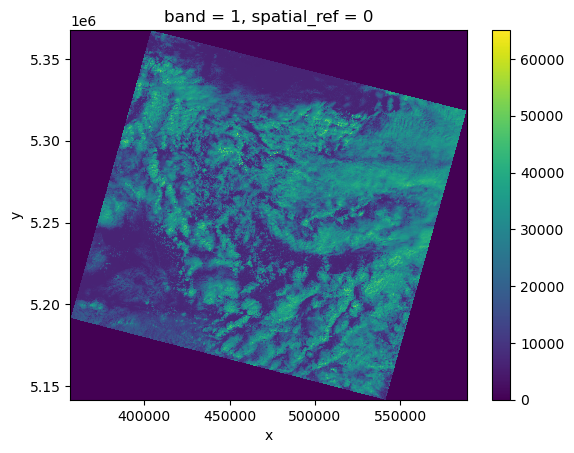

In [ ]:
xds = rioxarray.open_rasterio(
    "https://storage.googleapis.com/gcp-public-data-landsat/LC08/01/047/027/LC08_L1TP_047027_20130421_20170310_01_T1/LC08_L1TP_047027_20130421_20170310_01_T1_B4.TIF",
    chunks={'x': 2048, 'y': 2048} # tune chunks size to the memory
)
xds.sel(band=1).plot.imshow()
plt.show()

### Cloud Optimized GeoTIFFs (COGs) with overview levels

COGs embed pre-computed overview (pyramid) levels. It is possible to read a specific overview level directly via `rasterio`'s `overview_level` parameter, which is faster than loading the full resolution.

*Note: see also [Cloud Optimized GeoTiff (COG)](https://corteva.github.io/rioxarray/stable/examples/COG.html)*

In [ ]:
# from https://openaerialmap.org/
cog_url = (
    "https://oin-hotosm.s3.amazonaws.com/"
    "5d7dad0becaf880008a9bc88/0/5d7dad0becaf880008a9bc89.tif"
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


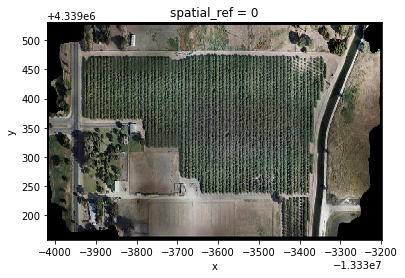

In [ ]:
xds = rioxarray.open_rasterio(cog_url, masked=True, overview_level=4)
xds.astype("int").plot.imshow(rgb="band")

## Preventing `spatial_ref = 0` in plot title

When plotting a `rioxarray` `DataArray`, `xarray` automatically adds all coordinates to the plot title, including `spatial_ref`, resulting in a plot title that is not necessarily chosen, like:

```
band = 1, spatial_ref = 0
```

Several ways exist to get rid of it:

- using [`.drop_vars()`](https://docs.xarray.dev/en/stable/generated/xarray.DataArray.drop_vars.html)

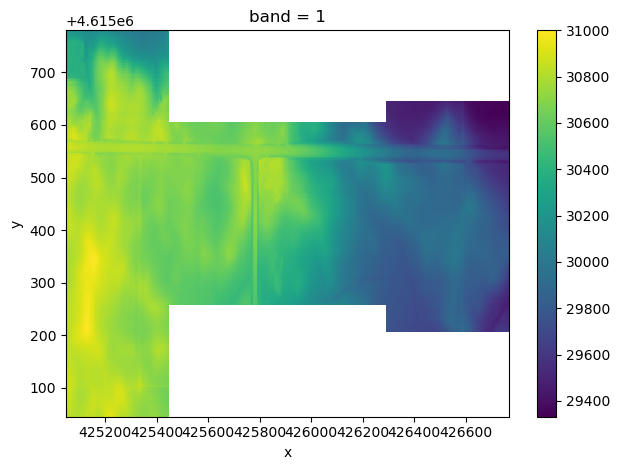

In [ ]:
xds = rioxarray.open_rasterio("../../test/test_data/compare/small_dem_3m_merged.tif", masked=True)
xds.drop_vars("spatial_ref").plot()
plt.show()

- specifying a title manually

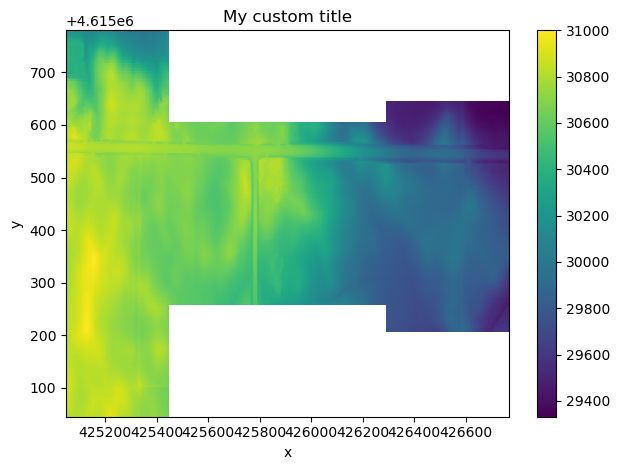

In [ ]:
xds = rioxarray.open_rasterio("../../test/test_data/compare/small_dem_3m_merged.tif", masked=True)
xds.plot()
plt.title("My custom title")
plt.show()

Further reading:

- *[xarray plotting documentation](https://docs.xarray.dev/en/stable/user-guide/plotting.html)*
- *[Open, Plot and Explore Raster Data with Python and Xarray](https://earthdatascience.org/courses/use-data-open-source-python/intro-raster-data-python/fundamentals-raster-data/open-lidar-raster-python-xarray/) by Earth Lab*